## I. Importing libraries

In [2]:
# Import libraries
import sys
import os
os.chdir(r"C:\Users\Admin\Downloads\ML_Researchers")
import torch

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
from sklearn.model_selection import train_test_split

from src.data import load_raw_data, preprocess_data, save_processed_data
from src.features import create_features
from src.models import train_models, evaluate_models, tune_hyperparameters, save_models, train_MLP, MLP
from src.visualization import classDistVisualize

## II. Preprocessing data

In [3]:
# Step 1: Load raw data
print("Loading raw data...")
raw_data = load_raw_data("data/raw/ted_talks_en.csv")
print("Raw Data Sample:")
print(raw_data.head())

Loading raw data...
Raw Data Sample:
   talk_id                            title         speaker_1  \
0        1      Averting the climate crisis           Al Gore   
1       92  The best stats you've ever seen      Hans Rosling   
2        7                 Simplicity sells       David Pogue   
3       53              Greening the ghetto     Majora Carter   
4       66      Do schools kill creativity?  Sir Ken Robinson   

              all_speakers                                    occupations  \
0           {0: 'Al Gore'}                      {0: ['climate advocate']}   
1      {0: 'Hans Rosling'}  {0: ['global health expert; data visionary']}   
2       {0: 'David Pogue'}                  {0: ['technology columnist']}   
3     {0: 'Majora Carter'}    {0: ['activist for environmental justice']}   
4  {0: 'Sir Ken Robinson'}                    {0: ['author', 'educator']}   

                                      about_speakers     views recorded_date  \
0  {0: 'Nobel Laureate Al Gor

In [4]:
# Step 2: Define target based on views
print("\nDefining target variable...")
median_views = raw_data['views'].median()
raw_data['target'] = raw_data['views'].apply(lambda x: 1 if x > median_views else 0)
print("Target Distribution:")
print(raw_data['target'].value_counts())


Defining target variable...
Target Distribution:
target
0    2003
1    2002
Name: count, dtype: int64


In [5]:
# Step 3: Preprocess the data
print("\nPreprocessing data...")
processed_data = preprocess_data(raw_data, text_column='transcript')
print("Processed Data Sample:")
print(processed_data.head())


Preprocessing data...
Processed Data Sample:
   talk_id                            title         speaker_1  \
0        1      Averting the climate crisis           Al Gore   
1       92  The best stats you've ever seen      Hans Rosling   
2        7                 Simplicity sells       David Pogue   
3       53              Greening the ghetto     Majora Carter   
4       66      Do schools kill creativity?  Sir Ken Robinson   

              all_speakers                                    occupations  \
0           {0: 'Al Gore'}                      {0: ['climate advocate']}   
1      {0: 'Hans Rosling'}  {0: ['global health expert; data visionary']}   
2       {0: 'David Pogue'}                  {0: ['technology columnist']}   
3     {0: 'Majora Carter'}    {0: ['activist for environmental justice']}   
4  {0: 'Sir Ken Robinson'}                    {0: ['author', 'educator']}   

                                      about_speakers     views recorded_date  \
0  {0: 'Nobel Laurea

In [6]:
# Save processed data
save_processed_data(processed_data, "data/processed/processed_ted_talks_en.csv")
print("\nProcessed data saved to 'data/processed/processed_ted_talks_en.csv'.")


Processed data saved to 'data/processed/processed_ted_talks_en.csv'.


In [7]:
# Step 4: Feature engineering (TF-IDF vectorization)
print("\nPerforming feature engineering...")
df_tfidf = create_features(processed_data, text_column='transcript', max_features=5000, ngram_range=(1, 2))
print("TF-IDF Data Sample:")
print(df_tfidf.head())


Performing feature engineering...
Shape of vectorized data: (4005, 5000)
Shape of TF-IDF DataFrame: (4005, 5000)
Sample of TF-IDF DataFrame:
        000  000 dollars  000 people  000 years        10    10 000  10 years  \
0  0.000000          0.0    0.000000        0.0  0.000000  0.000000  0.000000   
1  0.004605          0.0    0.000000        0.0  0.013543  0.000000  0.014897   
2  0.005165          0.0    0.000000        0.0  0.005064  0.000000  0.000000   
3  0.023866          0.0    0.011182        0.0  0.011699  0.022344  0.000000   
4  0.000000          0.0    0.000000        0.0  0.000000  0.000000  0.000000   

        100        11        12  ...  your body  your brain  your life  \
0  0.000000  0.000000  0.000000  ...        0.0         0.0        0.0   
1  0.017093  0.000000  0.000000  ...        0.0         0.0        0.0   
2  0.000000  0.025321  0.015327  ...        0.0         0.0        0.0   
3  0.000000  0.000000  0.000000  ...        0.0         0.0        0.0   
4

In [8]:
# Save vectorized data
df_tfidf.to_csv("data/processed/vectorized_data.csv", index=False)
print("\nVectorized data saved to 'data/processed/vectorized_data.csv'.")


Vectorized data saved to 'data/processed/vectorized_data.csv'.


In [9]:
# Step 5: Split data into train, validation, and test sets
print("\nSplitting data into train, validation, and test sets...")
X = df_tfidf.drop(columns=['target'])  # Features
y = df_tfidf['target']  # Target variable

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split train into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")


Splitting data into train, validation, and test sets...
Train set shape: (2563, 4999)
Validation set shape: (641, 4999)
Test set shape: (801, 4999)


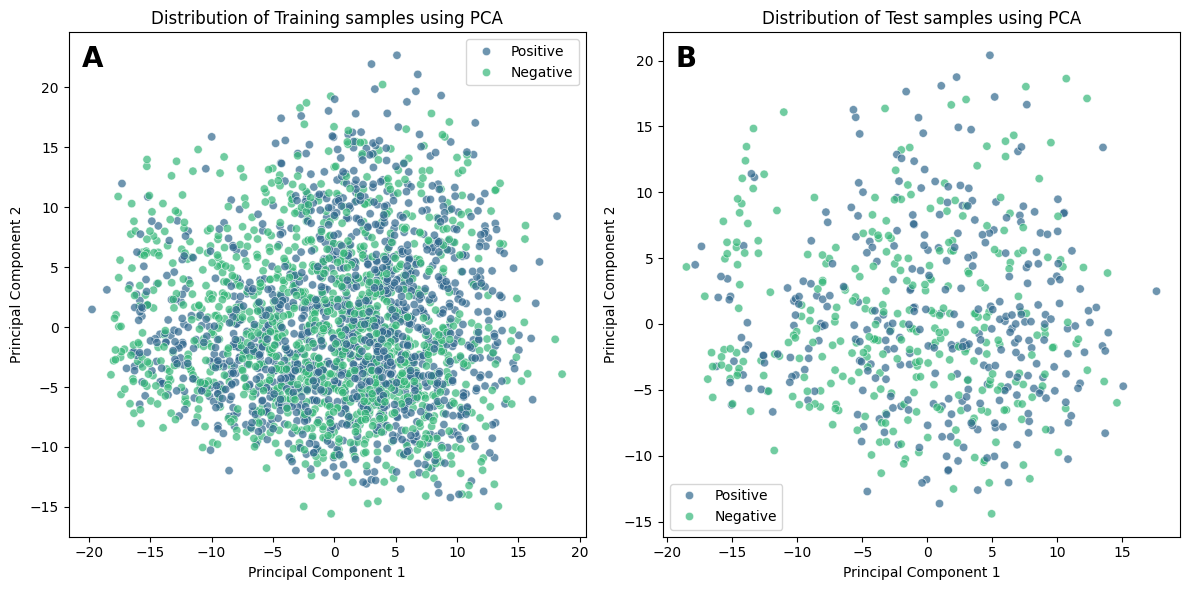

In [ ]:
# visualize the distribution of the variable on pca
train_data = [np.array(X_train), np.array(y_train)]
eval_data = [np.array(X_val), np.array(y_val)]
classDistVisualize('pca', train_data, eval_data)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 4.99 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.07 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.23 seconds
===> Running optimization with exaggeration=12.00, lr=213.58 for 250 iterations...
Iteration   50, KL divergence 5.1698, 50 iterations in 69.6008 sec
Iteration  100, KL divergence 5.4899, 50 iterations in 87.8525 sec
Iteration  150, KL divergence 5.0351, 50 iterations in 96.8627 sec
Iteration  200, KL divergence 5.4196, 50 iterations in 96.5361 sec
Iteration  250, KL divergence 5.2588, 50 iterations in 68.4460 sec
   --> Time elapsed: 419.30 seconds
===> Running optimization with exaggera

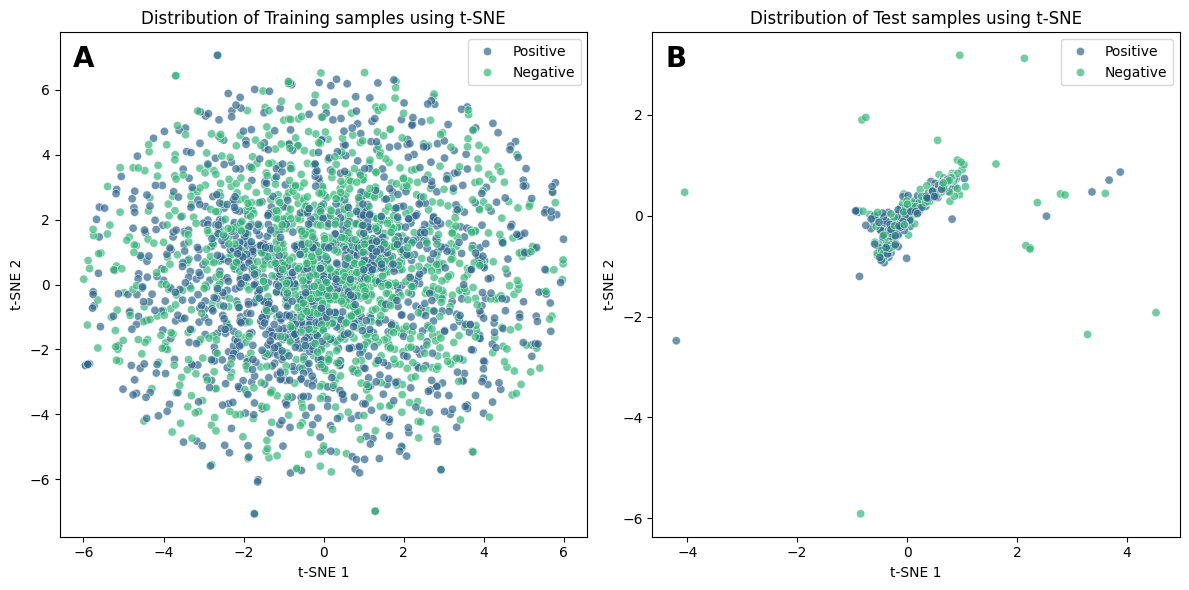

In [11]:
# visualize the distribution of the variable on tsne
classDistVisualize('tsne', train_data, eval_data)

In [8]:
# Step 6: Save test data for submission.ipynb
print("\nSaving test data for submission.ipynb...")
test_data = pd.concat([X_test, y_test], axis=1)
test_data.to_csv("data/processed/test_data.csv", index=False)
print("Test data saved to 'data/processed/test_data.csv'.")


Saving test data for submission.ipynb...
Test data saved to 'data/processed/test_data.csv'.


## III. Training models

In [11]:
from src.models.train_model import tune_reduced_dimension
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Step 7: Tune with reduced dimension
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10]
}

print("\nTuning hyperparameters (with dimensionality reduction)...")
best_model, best_params = tune_reduced_dimension(
    X_train, y_train, X_val, y_val,
    model_class=RandomForestClassifier,
    param_grid=param_grid,
    pca_components=2
)

# ---  Retrain full data train + val ---
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

print("\nRetraining best model on full train+val set...")
best_model.fit(X_full, y_full)

# Save reduced dimension model:
import joblib
joblib.dump(best_model, "models/trained/rf_pca_tuned.pkl")
print("Saved final tuned model to models/trained/rf_pca_tuned.pkl")



Tuning hyperparameters (with dimensionality reduction)...
Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 200}
Validation accuracy: 0.5373

Retraining best model on full train+val set...
Saved final tuned model to models/trained/rf_pca_tuned.pkl


In [ ]:
# Step 8: Hyperparameter tuning using GridSearchCV
print("\nPerforming hyperparameter tuning...")
best_models = tune_hyperparameters(X_train, y_train, X_val, y_val)


Performing hyperparameter tuning...

Tuning Logistic Regression...
Best parameters for Logistic Regression: {'C': 10, 'solver': 'liblinear'}
Validation accuracy for Logistic Regression: 0.6359923245614035

Tuning Ridge Classifier...
Best parameters for Ridge Classifier: {'alpha': 1.0}
Validation accuracy for Ridge Classifier: 0.6375525402046784

Tuning Decision Tree...


## IV. Evaluating models

In [ ]:
# Step 9: Evaluate the best models on the validation set
print("\nEvaluating best models on the validation set...")
val_results = evaluate_models(best_models, X_val, y_val)
print("Validation Set Evaluation Results:")
for model, metrics in val_results.items():
    print(f"{model}: {metrics}")


Evaluating best models on the validation set...
Validation Set Evaluation Results:
Logistic Regression: {'accuracy': 0.6302652106084243, 'precision': 0.6307890301882099, 'recall': 0.6302652106084243, 'f1': 0.6298489856538099}
Ridge Classifier: {'accuracy': 0.641185647425897, 'precision': 0.6415104269327732, 'recall': 0.641185647425897, 'f1': 0.640947947948313}
Decision Tree: {'accuracy': 0.5335413416536662, 'precision': 0.5347698390694248, 'recall': 0.5335413416536662, 'f1': 0.5298897063486557}
Random Forest: {'accuracy': 0.6193447737909517, 'precision': 0.6194900656679128, 'recall': 0.6193447737909517, 'f1': 0.619200190201262}
Gradient Boosting: {'accuracy': 0.6287051482059283, 'precision': 0.6290556446613836, 'recall': 0.6287051482059283, 'f1': 0.6284881520718633}
AdaBoost: {'accuracy': 0.5741029641185648, 'precision': 0.5741801100615452, 'recall': 0.5741029641185648, 'f1': 0.5740283211836729}
XGBoost: {'accuracy': 0.609984399375975, 'precision': 0.6100091275528577, 'recall': 0.6099

c:\Users\Admin\anaconda3\envs\firstVenv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Step 10: Train the best model on the entire train set (train + validation)
print("\nTraining the best model on the entire train set...")
best_model_name = max(val_results, key=lambda k: val_results[k]['accuracy'])
best_model = best_models[best_model_name]

# Combine train and validation sets
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train the best model
best_model.fit(X_train_full, y_train_full)


Training the best model on the entire train set...


SVC(C=1)

In [9]:
# Step 11: Train and evaluate on MLP model
model = train_MLP(X_train, y_train, X_val, y_val, X_test, y_test, input_size=4999, epochs=300, batch_size=32, lr=0.00001)

Epoch 1/300 - Train Loss: 0.6931, Val Loss: 0.6931, Val Acc: 0.5008
Epoch 2/300 - Train Loss: 0.6930, Val Loss: 0.6930, Val Acc: 0.5008
Epoch 3/300 - Train Loss: 0.6929, Val Loss: 0.6930, Val Acc: 0.5008
Epoch 4/300 - Train Loss: 0.6928, Val Loss: 0.6929, Val Acc: 0.5008
Epoch 5/300 - Train Loss: 0.6926, Val Loss: 0.6928, Val Acc: 0.5008
Epoch 6/300 - Train Loss: 0.6925, Val Loss: 0.6927, Val Acc: 0.5008
Epoch 7/300 - Train Loss: 0.6923, Val Loss: 0.6925, Val Acc: 0.5008
Epoch 8/300 - Train Loss: 0.6920, Val Loss: 0.6924, Val Acc: 0.5008
Epoch 9/300 - Train Loss: 0.6918, Val Loss: 0.6922, Val Acc: 0.5008
Epoch 10/300 - Train Loss: 0.6915, Val Loss: 0.6920, Val Acc: 0.5008
Epoch 11/300 - Train Loss: 0.6911, Val Loss: 0.6918, Val Acc: 0.5039
Epoch 12/300 - Train Loss: 0.6907, Val Loss: 0.6916, Val Acc: 0.5101
Epoch 13/300 - Train Loss: 0.6903, Val Loss: 0.6913, Val Acc: 0.5211
Epoch 14/300 - Train Loss: 0.6898, Val Loss: 0.6910, Val Acc: 0.5335
Epoch 15/300 - Train Loss: 0.6893, Val Loss

In [ ]:
# Step 12: Evaluate the best model on the test set
print("\nEvaluating the best model on the test set...")
test_results = evaluate_models({best_model_name: best_model}, X_test, y_test)
print(f"\n{best_model_name} Test Set Evaluation Results:")
for model, metrics in test_results.items():
    print(f"{model}: {metrics}")


Evaluating the best model on the test set...

SVM Test Set Evaluation Results:
SVM: {'accuracy': 0.6704119850187266, 'precision': 0.6707339796575976, 'recall': 0.6704119850187266, 'f1': 0.6704685022626748}


## V. Save models

In [10]:
# save the model mlp to trained folder
print("\nSaving MLP model...")
torch.save(model, "models/trained/mlp.pt")



Saving MLP model...


In [ ]:
# Step 13: Save the best model
print("\nSaving the best model...")
save_models({best_model_name: best_model})
print(f"Best model ({best_model_name}) saved to 'models/trained/'.")


Saving the best model...


NameError: name 'save_models' is not defined